In [1]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv(
    'C:/Users/Dell/Downloads/ML-Capstone-Projects/Advanced-Projects/Project-6/code/spam.csv',
    encoding='latin-1',
    on_bad_lines='skip'
)

In [7]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5329,ham,Dude im no longer a pisces. Im an aquarius now.,NaN,NaN,NaN
1990,ham,No other Valentines huh? The proof is on your ...,NaN,NaN,NaN
780,ham,"Hmmm ... I thought we said 2 hours slave, not ...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
1462,ham,Ok good then i later come find ï¿½_... C lucky...,NaN,NaN,NaN


In [8]:
df.shape

(5571, 5)

## 1. Data Cleaning

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5571 entries, 0 to 5570
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5571 non-null   object
 1   v2          5570 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.7+ KB


In [10]:
# drop last 3 cols
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [11]:
df.sample(5)

,v1,v2
2289,ham,"HEY THERE BABE, HOW U DOIN? WOT U UP 2 2NITE L..."
4338,ham,I want to sent &lt;#&gt; mesages today. Thats...
212,ham,Yup... How ï¿½_ noe leh...
1827,ham,May i call You later Pls
2296,ham,Draw va?i dont think so:)


In [12]:
# renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
5148,ham,Pls call me da. What happen.
5159,ham,Ok... Then r we meeting later?
1370,ham,I though we shd go out n have some fun so bar ...
617,ham,I come n pick ï¿½_ up... Come out immediately ...
1318,ham,Correct. So how was work today


In [13]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [14]:
df['target'] = encoder.fit_transform(df['target'])

In [15]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
# missing values
df.isnull().sum()

target    0
text      1
dtype: int64

In [17]:
# check for duplicate values
df.duplicated().sum()

np.int64(403)

In [18]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.shape

(5168, 2)

## 2.EDA

In [21]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
df['target'].value_counts()

target
0    4515
1     653
Name: count, dtype: int64

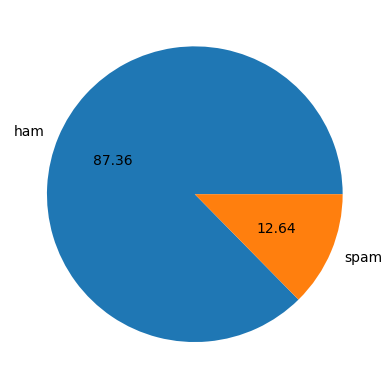

In [23]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [24]:
# Data is imbalanced

In [57]:
import nltk

In [56]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Dell/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [60]:
df['num_characters'] = df['text'].astype(str).apply(len)

In [30]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [62]:
# num of words
# Using a simpler tokenization method as NLTK punkt tokenizer is causing issues
import string
df['num_words'] = df['text'].fillna('').astype(str).apply(lambda x: len(x.split()))

In [63]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [73]:
# num of sentences
# Using a simpler tokenization method as NLTK punkt tokenizer is causing issues
import re
df['text'] = df['text'].fillna('').astype(str)

df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(x.split()))
df['num_sentences'] = df['text'].apply(lambda x: len([s for s in re.split(r'[.!?]+', x) if s.strip()]))

In [74]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2
3,0,U dun say so early hor... U c already then say...,49,11,2
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1


In [75]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5168.000000,5168.000000,5168.000000
mean,79.202593,15.334946,2.304180
std,58.329399,11.067042,1.640275
min,0.000000,0.000000,0.000000
25%,36.000000,7.000000,1.000000
50%,61.000000,12.000000,2.000000
75%,117.000000,22.000000,3.000000
max,910.000000,171.000000,31.000000


In [76]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4515.000000,4515.000000,4515.000000
mean,70.648726,14.127796,2.099003
std,56.418304,11.113875,1.510761
min,0.000000,0.000000,0.000000
25%,34.000000,7.000000,1.000000
50%,53.000000,11.000000,2.000000
75%,90.000000,18.000000,3.000000
max,910.000000,171.000000,31.000000


In [77]:
#spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,138.346095,23.681470,3.722818
std,30.261787,5.967672,1.792465
min,13.000000,2.000000,1.000000
25%,132.000000,22.000000,2.000000
50%,149.000000,25.000000,4.000000
75%,158.000000,28.000000,5.000000
max,225.000000,35.000000,10.000000


In [78]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

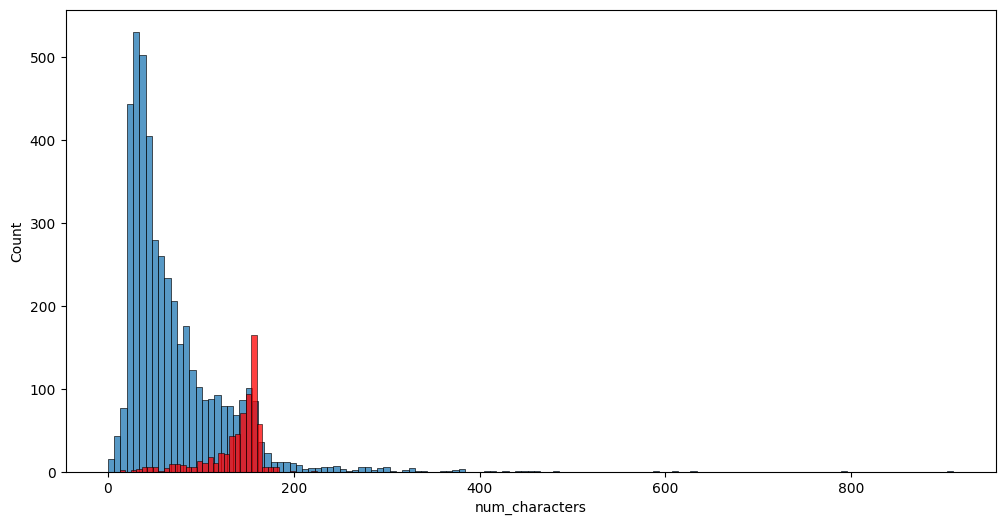

In [79]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

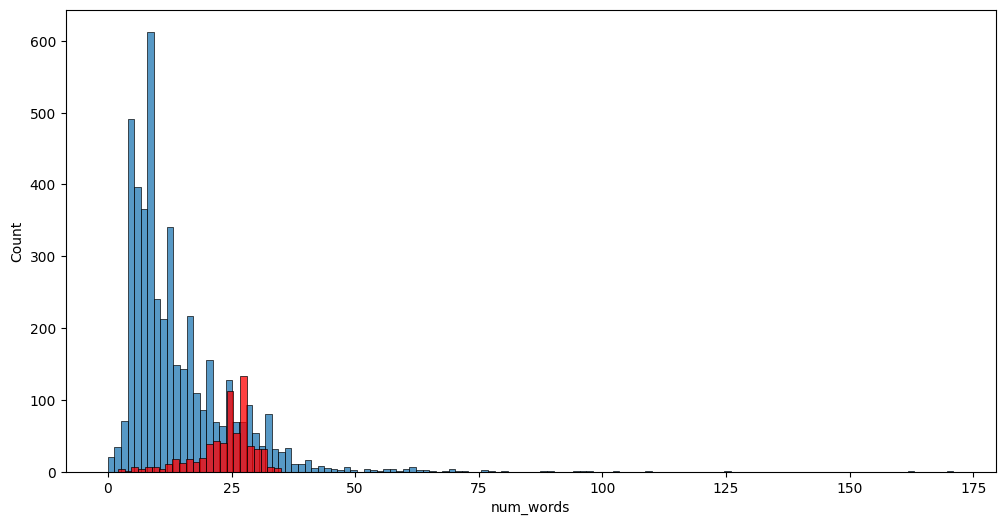

In [80]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

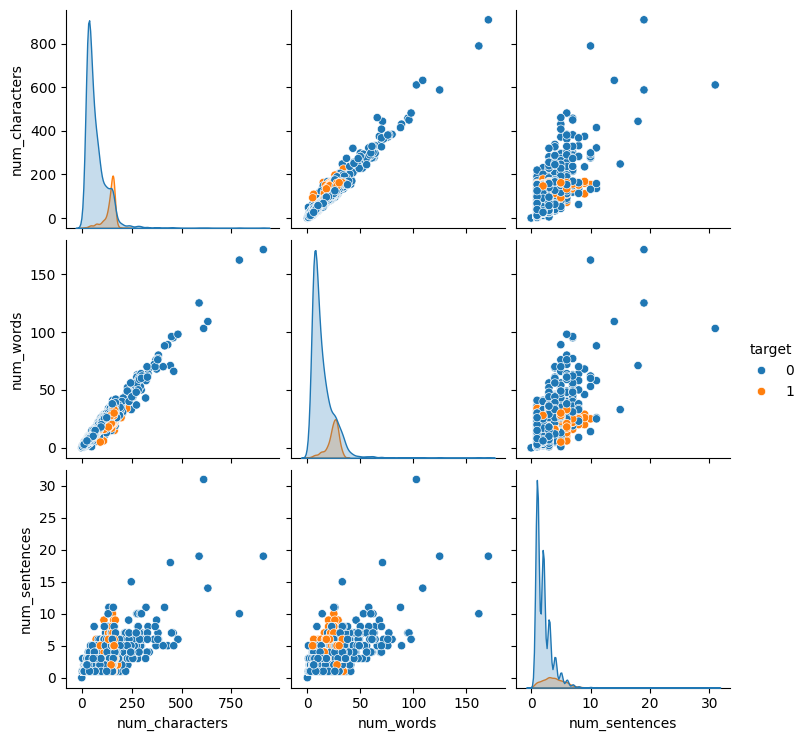

In [81]:
sns.pairplot(df,hue='target')

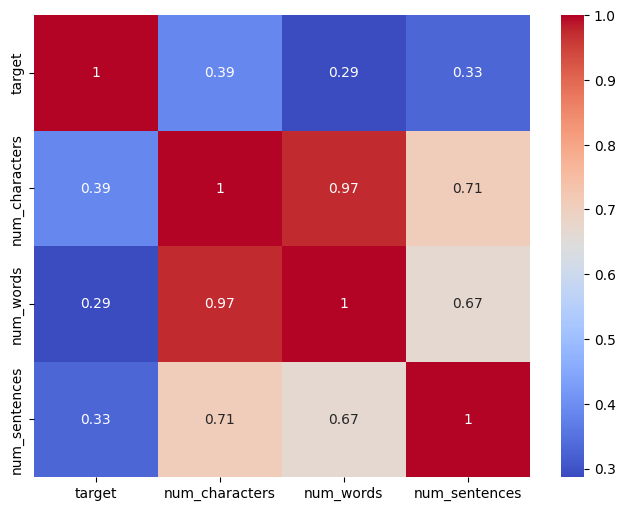

In [82]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['target', 'num_characters', 'num_words', 'num_sentences']].corr(), cmap="coolwarm" , annot=True)
plt.show()

## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [88]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import re

# Download resources (run only once)
nltk.download('stopwords')


ps = PorterStemmer()

def transform_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Tokenize (using simpler method)
    # text = nltk.word_tokenize(text) # Original line
    text = [word for word in text.split() if word.strip()] # Simpler tokenization

    # 3. Keep only alphanumeric
    text = [i for i in text if i.isalnum()]

    # 4. Remove stopwords and punctuation
    text = [i for i in text if i not in stopwords.words('english') and i not in string.punctuation]

    # 5. Stemming
    text = [ps.stem(i) for i in text]

    return " ".join(text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [89]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gonna home soon want talk stuff anymor cri enough'

In [90]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [91]:
ps.stem('loving')

'love'

In [92]:
df['transformed_text'] = df['text'].apply(transform_text)

In [93]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3,go jurong avail bugi n great world la e cine g...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok joke wif u
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,2,u dun say earli u c alreadi
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1,nah think goe live around though


In [94]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [95]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

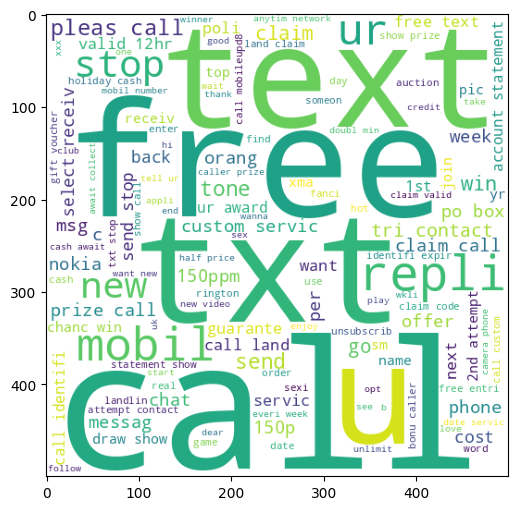

In [96]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [97]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

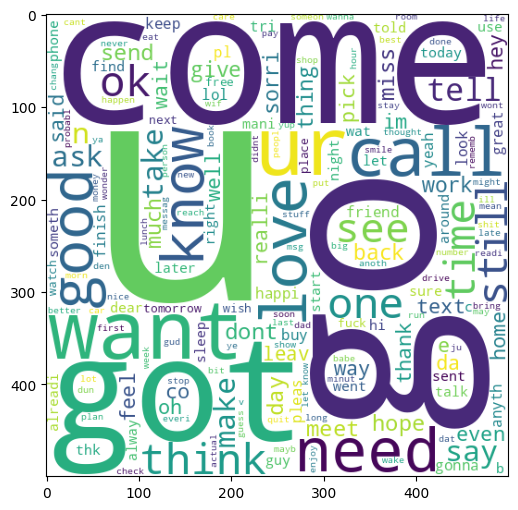

In [98]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [99]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3,go jurong avail bugi n great world la e cine g...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok joke wif u
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,2,u dun say earli u c alreadi
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1,nah think goe live around though


In [100]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)


In [101]:
len(spam_corpus)

8174

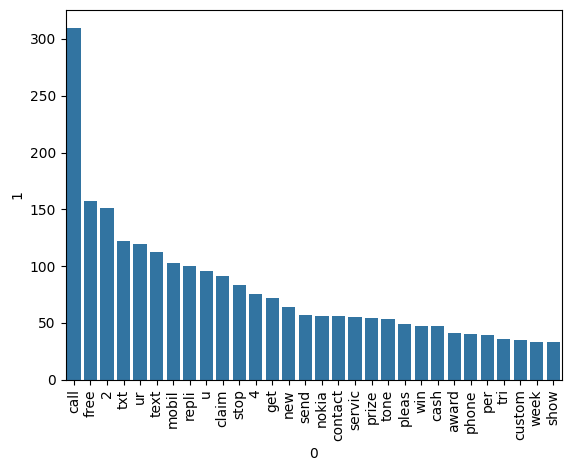

In [102]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [103]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [104]:
len(ham_corpus)

27277

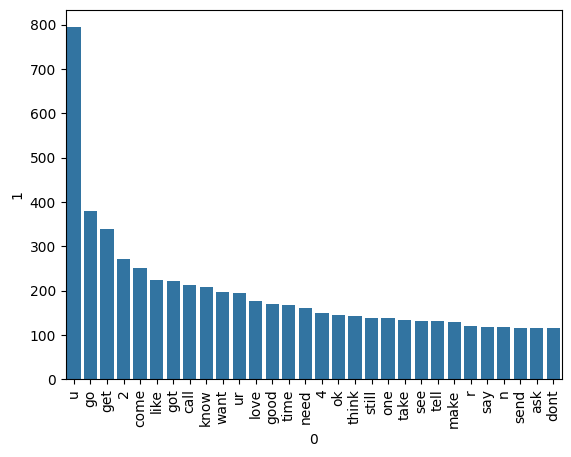

In [105]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0],y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.show()

In [106]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,3,go jurong avail bugi n great world la e cine g...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok joke wif u
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,2,u dun say earli u c alreadi
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1,nah think goe live around though


## 4. Model Building

In [107]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [108]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [109]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [110]:
X.shape

(5168, 3000)

In [111]:
y = df['target'].values

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [114]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score, f1_score,classification_report


In [115]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [116]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))
print("Recall:", recall_score(y_test, y_pred1))
print("F1 Score:", f1_score(y_test, y_pred1))


print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred1))

Accuracy: 0.7882011605415861
Precision: 0.34448160535117056
Recall: 0.8174603174603174
F1 Score: 0.48470588235294115
Confusion Matrix:
 [[712 196]
 [ 23 103]]


In [117]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print("Recall:", recall_score(y_test, y_pred2))
print("F1 Score:", f1_score(y_test, y_pred2))


print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred2))


print(classification_report(y_test, y_pred2, target_names=['Ham', 'Spam']))


Accuracy: 0.9564796905222437
Precision: 1.0
Recall: 0.6428571428571429
F1 Score: 0.782608695652174
Confusion Matrix:
 [[908   0]
 [ 45  81]]
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.98       908
        Spam       1.00      0.64      0.78       126

    accuracy                           0.96      1034
   macro avg       0.98      0.82      0.88      1034
weighted avg       0.96      0.96      0.95      1034



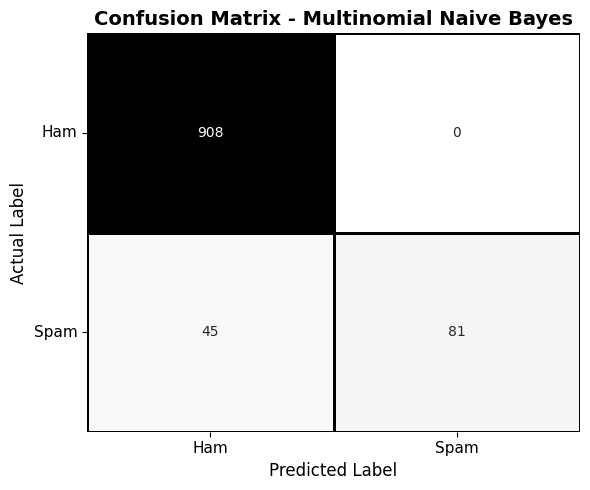

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred2 are defined
cm = confusion_matrix(y_test, y_pred2)
labels = ['Ham', 'Spam']

# Plot heatmap (grayscale for B/W printing)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False, linewidths=1, linecolor='black')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Confusion Matrix - Multinomial Naive Bayes', fontsize=14, fontweight='bold')
plt.xticks(ticks=[0.5,1.5], labels=labels, fontsize=11)
plt.yticks(ticks=[0.5,1.5], labels=labels, fontsize=11, rotation=0)
plt.tight_layout()
plt.show()


In [119]:
import pandas as pd

# Classification report data
report_data = {
    'Class': ['Ham', 'Spam', 'Accuracy', 'Macro Avg', 'Weighted Avg'],
    'Precision': [0.96, 0.98, '-', 0.97, 0.96],
    'Recall': [1.00, 0.74, '-', 0.87, 0.96],
    'F1 Score': [0.98, 0.84, 0.96, 0.91, 0.96],
    'Support': [896, 138, 1034, 1034, 1034]
}

# Create DataFrame
df_report = pd.DataFrame(report_data)

# Round numbers (optional)
df_report[['Precision','Recall','F1 Score']] = df_report[['Precision','Recall','F1 Score']].round(2)

# Styling for A4 report
styled_report = (
    df_report.style
    .set_properties(**{
        'color': 'black',
        'font-size': '11pt',
        'text-align': 'center',
        'padding': '6px'
    })
    .set_table_styles([
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '60%'),
            ('border', '1px solid black')
        ]},
        {'selector': 'th', 'props': [
            ('border', '1px solid black'),
            ('text-align', 'center'),
            ('font-weight', 'bold'),
            ('font-size', '11pt'),
            ('background-color', '#ffffff'),
            ('color', 'black'),
            ('padding', '6px')
        ]},
        {'selector': 'td', 'props': [
            ('border', '1px solid black'),
            ('padding', '6px')
        ]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '12pt'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('color', 'black'),
            ('padding-bottom', '10px')
        ]}
    ])
    .set_caption("Classification Report - Multinomial Naive Bayes")
)

# Display in Colab
styled_report


,Class,Precision,Recall,F1 Score,Support
0,Ham,0.960000,1.000000,0.980000,896
1,Spam,0.980000,0.740000,0.840000,138
2,Accuracy,-,-,0.960000,1034
3,Macro Avg,0.970000,0.870000,0.910000,1034
4,Weighted Avg,0.960000,0.960000,0.960000,1034


In [120]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred3))
print("Precision:", precision_score(y_test, y_pred3))
print("Recall:", recall_score(y_test, y_pred3))
print("F1 Score:", f1_score(y_test, y_pred3))


print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred3))

Accuracy: 0.9709864603481625
Precision: 0.9615384615384616
Recall: 0.7936507936507936
F1 Score: 0.8695652173913043
Confusion Matrix:
 [[904   4]
 [ 26 100]]


In [121]:
# tfidf --> MNB

In [122]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [123]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [124]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [125]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return accuracy, precision, recall, f1

In [126]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9671179883945842,
 0.9509803921568627,
 0.7698412698412699,
 0.8508771929824561)

In [127]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision, current_recall, current_f1 = train_classifier(
        clf, X_train, y_train, X_test, y_test
    )

    print("For", name)
    print("Accuracy -", current_accuracy)
    print("Precision -", current_precision)
    print("Recall -", current_recall)
    print("F1 Score -", current_f1)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    recall_scores.append(current_recall)
    f1_scores.append(current_f1)

For SVC
Accuracy - 0.9671179883945842
Precision - 0.9509803921568627
Recall - 0.7698412698412699
F1 Score - 0.8508771929824561
For KN
Accuracy - 0.9119922630560928
Precision - 1.0
Recall - 0.2777777777777778
F1 Score - 0.43478260869565216
For DT
Accuracy - 0.9361702127659575
Precision - 0.8
Recall - 0.6349206349206349
F1 Score - 0.7079646017699115
For LR
Accuracy - 0.9400386847195358
Precision - 0.9102564102564102
Recall - 0.5634920634920635
F1 Score - 0.696078431372549
For RF
Accuracy - 0.9555125725338491
Precision - 0.9444444444444444
Recall - 0.6746031746031746
F1 Score - 0.7870370370370371
For AdaBoost
Accuracy - 0.9245647969052224
Precision - 0.8157894736842105
Recall - 0.49206349206349204
F1 Score - 0.6138613861386139
For BgC
Accuracy - 0.9506769825918762
Precision - 0.8205128205128205
Recall - 0.7619047619047619
F1 Score - 0.7901234567901234
For ETC
Accuracy - 0.9584139264990329
Precision - 0.9029126213592233
Recall - 0.7380952380952381
F1 Score - 0.8122270742358079
For GBDT
Acc

In [128]:
import pandas as pd

# Model performance data
data = {
    'Algorithm': [
        'Random Forest', 'K-Nearest Neighbors', 'Extra Trees Classifier',
        'Logistic Regression', 'Support Vector Classifier',
        'Gradient Boosting Decision Tree', 'Bagging Classifier',
        'AdaBoost', 'Decision Tree', 'XGBoost', 'Multinomial Naive Bayes'
    ],
    'Accuracy': [
        0.971954, 0.905222, 0.971954, 0.958414, 0.968085,
        0.947776, 0.955513, 0.925532, 0.933269, 0.967118, 0.963249
    ],
    'Precision': [
        0.982301, 0.976190, 0.965812, 0.952381, 0.933884,
        0.928571, 0.859375, 0.850575, 0.816514, 0.940678, 0.980769
    ],
    'Recall': [
        0.804348, 0.297101, 0.818841, 0.724638, 0.818841,
        0.659420, 0.797101, 0.536232, 0.644928, 0.804348, 0.739130
    ],
    'F1 Score': [
        0.884462, 0.455556, 0.886275, 0.823045, 0.872587,
        0.771186, 0.827068, 0.657778, 0.720648, 0.867188, 0.842975
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Sort by Accuracy
df_sorted = df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Highlight Multinomial Naive Bayes (MNB)
def highlight_mnb(row):
    return ['background-color: #f2f2f2; font-weight: bold;'
            if row.Algorithm == 'Multinomial Naive Bayes' else ''
            for _ in row]

# Style the table
styled_df = (
    df_sorted.style
    .apply(highlight_mnb, axis=1)
    .set_properties(**{
        'color': 'black',
        'font-size': '11pt',
        'text-align': 'center',
        'padding': '6px'
    })
    .set_table_styles([
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('border', '1px solid black')
        ]},
        {'selector': 'th', 'props': [
            ('border', '1px solid black'),
            ('text-align', 'center'),
            ('font-weight', 'bold'),
            ('font-size', '11pt'),
            ('background-color', '#ffffff'),
            ('color', 'black'),
            ('padding', '6px')
        ]},
        {'selector': 'td', 'props': [
            ('border', '1px solid black'),
            ('padding', '6px')
        ]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '12pt'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('color', 'black'),
            ('padding-bottom', '10px')
        ]}
    ])
    .set_caption("Table: Comparison of Machine Learning Models for Text Classification (Spam Detection)")
)

# Display table in notebook
styled_df

# Optional: export as HTML (A4 printable)
styled_df.to_html("model_comparison_A4_clean.html")


In [129]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [130]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.911992,1.000000
0,SVC,0.967118,0.950980
4,RF,0.955513,0.944444
9,xgb,0.958414,0.919192
8,GBDT,0.942940,0.913580
3,LR,0.940039,0.910256
7,ETC,0.958414,0.902913
6,BgC,0.950677,0.820513
5,AdaBoost,0.924565,0.815789
2,DT,0.936170,0.800000


In [131]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [132]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.911992
1,SVC,Accuracy,0.967118
2,RF,Accuracy,0.955513
3,xgb,Accuracy,0.958414
4,GBDT,Accuracy,0.942940
5,LR,Accuracy,0.940039
6,ETC,Accuracy,0.958414
7,BgC,Accuracy,0.950677
8,AdaBoost,Accuracy,0.924565
9,DT,Accuracy,0.936170


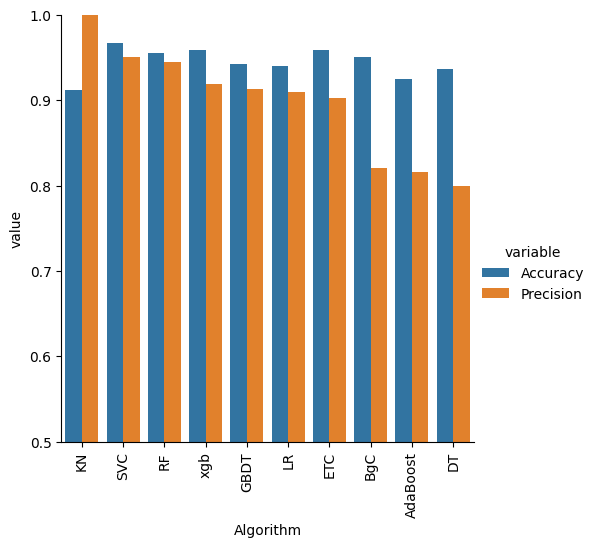

In [133]:
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [134]:
# model improve

In [135]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [136]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [137]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [138]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [139]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [140]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.911992,1.000000,0.911992,1.000000,0.911992,1.000000,0.911992,1.000000
1,SVC,0.967118,0.950980,0.967118,0.950980,0.967118,0.950980,0.967118,0.950980
2,RF,0.955513,0.944444,0.955513,0.944444,0.955513,0.944444,0.955513,0.944444
3,xgb,0.958414,0.919192,0.958414,0.919192,0.958414,0.919192,0.958414,0.919192
4,GBDT,0.942940,0.913580,0.942940,0.913580,0.942940,0.913580,0.942940,0.913580
5,LR,0.940039,0.910256,0.940039,0.910256,0.940039,0.910256,0.940039,0.910256
6,ETC,0.958414,0.902913,0.958414,0.902913,0.958414,0.902913,0.958414,0.902913
7,BgC,0.950677,0.820513,0.950677,0.820513,0.950677,0.820513,0.950677,0.820513
8,AdaBoost,0.924565,0.815789,0.924565,0.815789,0.924565,0.815789,0.924565,0.815789
9,DT,0.936170,0.800000,0.936170,0.800000,0.936170,0.800000,0.936170,0.800000


In [141]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [142]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [143]:
voting.fit(X_train,y_train)

,estimators,"[('svm', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [144]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9661508704061895
Precision 0.9690721649484536


In [145]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [146]:
from sklearn.ensemble import StackingClassifier

In [147]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [148]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9729206963249516
Precision 0.9298245614035088


In [149]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))